In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = "path_to_train_folder"
val_dir = "path_to_val_folder"
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

In [3]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\afrin\Downloads\Plantvillage\PlantVillage\train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\afrin\Downloads\Plantvillage\PlantVillage\train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)


Found 43444 files belonging to 38 classes.
Using 34756 files for training.
Found 43444 files belonging to 38 classes.
Using 8688 files for validation.


In [4]:
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\afrin\Downloads\Plantvillage\PlantVillage\val",
    image_size=(224, 224),
    batch_size=32
)

Found 10861 files belonging to 38 classes.


In [5]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(38, activation='softmax')  # 38 classes
])

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)    

In [7]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\afrin\Downloads\Plantvillage\PlantVillage\train",
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\afrin\Downloads\Plantvillage\PlantVillage\val",
    image_size=(224, 224),
    batch_size=32
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Found 43444 files belonging to 38 classes.
Found 10861 files belonging to 38 classes.
Epoch 1/10
1358/1358 [==============================] - 6342s 5s/step - loss: 3.2343 - accuracy: 0.5410 - val_loss: 0.9413 - val_accuracy: 0.7224
Epoch 2/10
1358/1358 [==============================] - 6282s 5s/step - loss: 0.6633 - accuracy: 0.8000 - val_loss: 1.0312 - val_accuracy: 0.7278
Epoch 3/10
1358/1358 [==============================] - 6364s 5s/step - loss: 0.3462 - accuracy: 0.8919 - val_loss: 0.7665 - val_accuracy: 0.8003
Epoch 4/10
1358/1358 [==============================] - 6409s 5s/step - loss: 0.2272 - accuracy: 0.9296 - val_loss: 1.0503 - val_accuracy: 0.7825
Epoch 5/10
1358/1358 [==============================] - 6443s 5s/step - loss: 0.1886 - accuracy: 0.9434 - val_loss: 1.0337 - val_accuracy: 0.8044
Epoch 6/10
1358/1358 [==============================] - 6434s 5s/step - loss: 1.2884 - accuracy: 0.6637 - val_loss: 3.1354 - val_accuracy: 0.1578
Epoch 7/10
1358/1358 [================

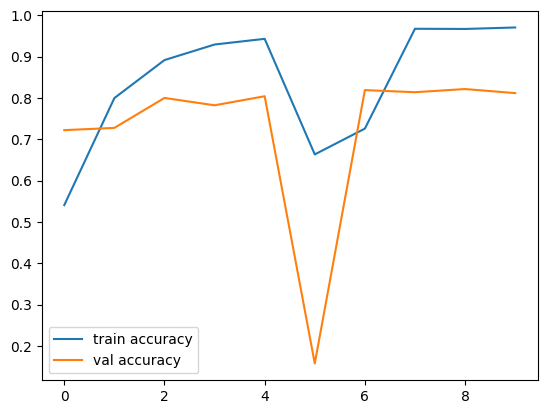

In [8]:
plt.plot(history.history['accuracy'],
         label='train accuracy')
plt.plot(history.history['val_accuracy'],
         label='val accuracy')
plt.legend()
plt.show()


In [9]:
base_model = tf.keras.application.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)    

AttributeError: module 'tensorflow.keras' has no attribute 'application'